# Import Libraries

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# EDA

In [18]:
df=pd.read_csv("loan_data.csv")

In [19]:
df.head(10) # target is loan_status

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [21]:
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


# cleaning outliers

In [24]:
df=df[ df["person_age"] <= 90]

In [25]:
df=df[ df["person_emp_exp"] <= 50]

In [26]:
df=df[ df["person_age"] > df["person_emp_exp"]]

In [27]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44988.000000,4.498800e+04,44988.000000,44988.000000,44988.000000,44988.000000,44988.000000,44988.000000,44988.000000
mean,27.742354,7.990907e+04,5.388148,9583.323820,11.006634,0.139738,5.864408,632.573308,0.222281
std,5.881527,6.332489e+04,5.896067,6314.994983,2.979042,0.087209,3.872007,50.389790,0.415784
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.719425e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704550e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.577900e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,73.000000,2.448661e+06,50.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


<Axes: >

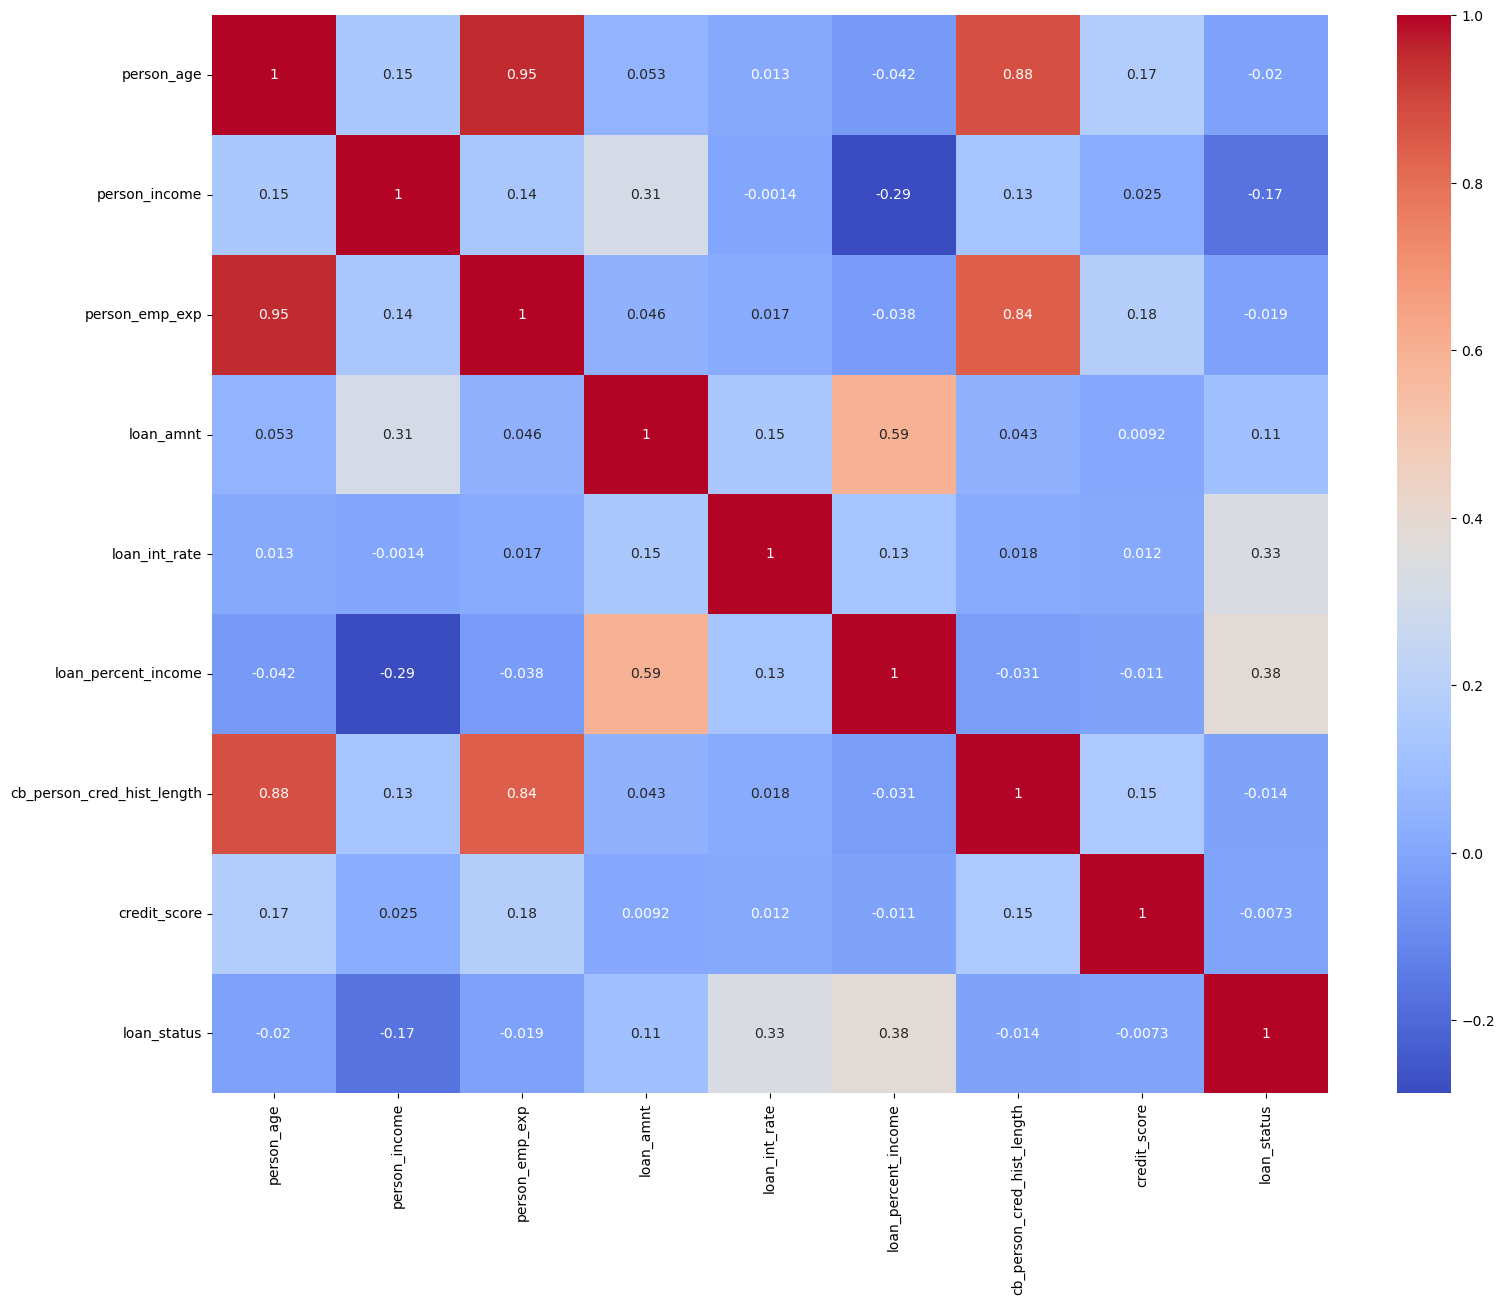

In [28]:
plt.figure(figsize=(18,14))
numeric_data=df.select_dtypes(include=('Float64','int64'))
sns.heatmap(numeric_data.corr(),annot=True,cmap='coolwarm')

# preprocessing

In [29]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split


In [30]:
df['person_age']=df['person_age'].astype('int64[pyarrow]')

In [31]:
df['previous_loan_defaults_on_file']=df['previous_loan_defaults_on_file'].map({'No':0,'Yes':1})

In [32]:
df['person_gender']=df['person_gender'].map({'male':1,'female':0})

In [33]:
catgorical_columns=['person_education','person_home_ownership','loan_intent']
LabelEncoder=LabelEncoder()
for i in catgorical_columns:
    df[i]=LabelEncoder.fit_transform(df[i])

In [34]:
x=df.drop(['loan_status'],axis=1)
y=df['loan_status']

In [35]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [36]:
x.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file'],
      dtype='object')

In [37]:
numeric_columns=['person_age', 'person_gender', 'person_education', 'person_income',
'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
'credit_score', 'previous_loan_defaults_on_file']

In [38]:
StandardScaler=StandardScaler()
x_train=StandardScaler.fit_transform(x_train[numeric_columns])

In [39]:
x_test=StandardScaler.transform(x_test[numeric_columns])

In [40]:
x_train

array([[-0.4648249 ,  0.90313862, -0.50396127, ..., -0.74141458,
         0.38460419, -1.01449797],
       [ 0.90291912, -1.10724974,  0.84752088, ...,  0.5587867 ,
         0.02665835, -1.01449797],
       [ 1.24485513, -1.10724974,  1.52326196, ...,  0.03870619,
         0.12608775,  0.98570922],
       ...,
       [-0.8067609 , -1.10724974, -1.17970235, ..., -0.48137432,
         0.62323476,  0.98570922],
       [-0.2938569 , -1.10724974, -0.50396127, ..., -0.48137432,
         0.38460419, -1.01449797],
       [-0.6357929 , -1.10724974,  0.84752088, ..., -0.48137432,
         0.52380536,  0.98570922]])

# Model

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
Model=LogisticRegression()

In [43]:
Model.fit(x_train,y_train)

LogisticRegression()

In [44]:
y_pred=Model.predict(x_test)

In [45]:
y_test

33189    0
28555    0
18789    0
18720    0
14503    0
        ..
34247    0
15385    0
31469    0
17987    0
38968    0
Name: loan_status, Length: 8998, dtype: int64

In [46]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

# Evaluate Model

In [47]:
from sklearn.metrics import classification_report,confusion_matrix

In [48]:
classification_report=classification_report(y_test,y_pred)
print("the evaluation is : ",classification_report)

#الموديل قدر يتوقع 6999 حاله قالهم لا 

#  وي قدر يتوقع 1999 يقولهم ايوه ياخدو القرض

# في حالالت القبول قدر يقبل 77 من الناس بس ادي القرض لي ناس قيمتهم 23 وي هما مش مؤهلين precision

# الموديل قدر يلقط 75 من الناس الي هيخدو القرض وي مؤهلين  بس ظلم 25 مؤهلين انهم مياخدوش recall

the evaluation is :                precision    recall  f1-score   support

           0       0.93      0.94      0.93      6999
           1       0.77      0.75      0.76      1999

    accuracy                           0.90      8998
   macro avg       0.85      0.84      0.85      8998
weighted avg       0.89      0.90      0.89      8998



In [49]:
confusion_matrix=confusion_matrix(y_test,y_pred)
print("the evaluation of confusion_matrix is : ",confusion_matrix)

the evaluation of confusion_matrix is :  [[6564  435]
 [ 505 1494]]


# Save Model

In [50]:
import joblib
joblib.dump(Model,'model_loan.pkl')

['model_loan.pkl']

In [51]:
x.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file'],
      dtype='object')